In [111]:
# Importando bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configuração global de gráficos
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

In [112]:
# Carregando os datasets
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs  = pd.read_csv('/datasets/costs_us.csv')

In [113]:
# Inspeção inicial
for name, df in [('visits', visits), ('orders', orders), ('costs', costs)]:
    print(f'=== {name} ===')
    print(df.info())
    print(df.head(3))
    print()

=== visits ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
None
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  

=== orders ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  D

In [114]:
# Convertendo colunas de data para datetime
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts']   = pd.to_datetime(visits['End Ts'])
orders['Buy Ts']   = pd.to_datetime(orders['Buy Ts'])
costs['dt']        = pd.to_datetime(costs['dt'])

# Validação dos tipos após conversão
print('visits:'); print(visits.dtypes)
print('\norders:'); print(orders.dtypes)
print('\ncosts:');  print(costs.dtypes)

visits:
Device               object
End Ts       datetime64[ns]
Source Id             int64
Start Ts     datetime64[ns]
Uid                  uint64
dtype: object

orders:
Buy Ts     datetime64[ns]
Revenue           float64
Uid                uint64
dtype: object

costs:
source_id             int64
dt           datetime64[ns]
costs               float64
dtype: object


In [115]:
# Enriquecimento da tabela de visitas com colunas auxiliares
visits['session_duration'] = (visits['End Ts'] - visits['Start Ts']).dt.total_seconds()
visits['date']  = visits['Start Ts'].dt.date
visits['week']  = visits['Start Ts'].dt.to_period('W')
visits['month'] = visits['Start Ts'].dt.to_period('M')

# Primeira visita por usuário
first_visit = visits.groupby('Uid')['Start Ts'].min().rename('first_visit_ts')
visits = visits.merge(first_visit, on='Uid')
visits['first_visit_month'] = visits['first_visit_ts'].dt.to_period('M')

print(visits[['Uid','session_duration','date','week','month','first_visit_month']].head(3))

                    Uid  session_duration        date                   week  \
0  16879256277535980062            1080.0  2017-12-20  2017-12-18/2017-12-24   
1    104060357244891740            1680.0  2018-02-19  2018-02-19/2018-02-25   
2   7459035603376831527               0.0  2017-07-01  2017-06-26/2017-07-02   

     month first_visit_month  
0  2017-12           2017-12  
1  2018-02           2018-02  
2  2017-07           2017-07  


In [116]:
#Usuários Ativos por Dia, Semana e Mês (DAU / WAU / MAU)
dau = visits.groupby('date')['Uid'].nunique()
wau = visits.groupby('week')['Uid'].nunique()
mau = visits.groupby('month')['Uid'].nunique()

print(f'DAU médio: {dau.mean():.0f} usuários/dia')
print(f'WAU médio: {wau.mean():.0f} usuários/semana')
print(f'MAU médio: {mau.mean():.0f} usuários/mês')

DAU médio: 908 usuários/dia
WAU médio: 5716 usuários/semana
MAU médio: 23228 usuários/mês


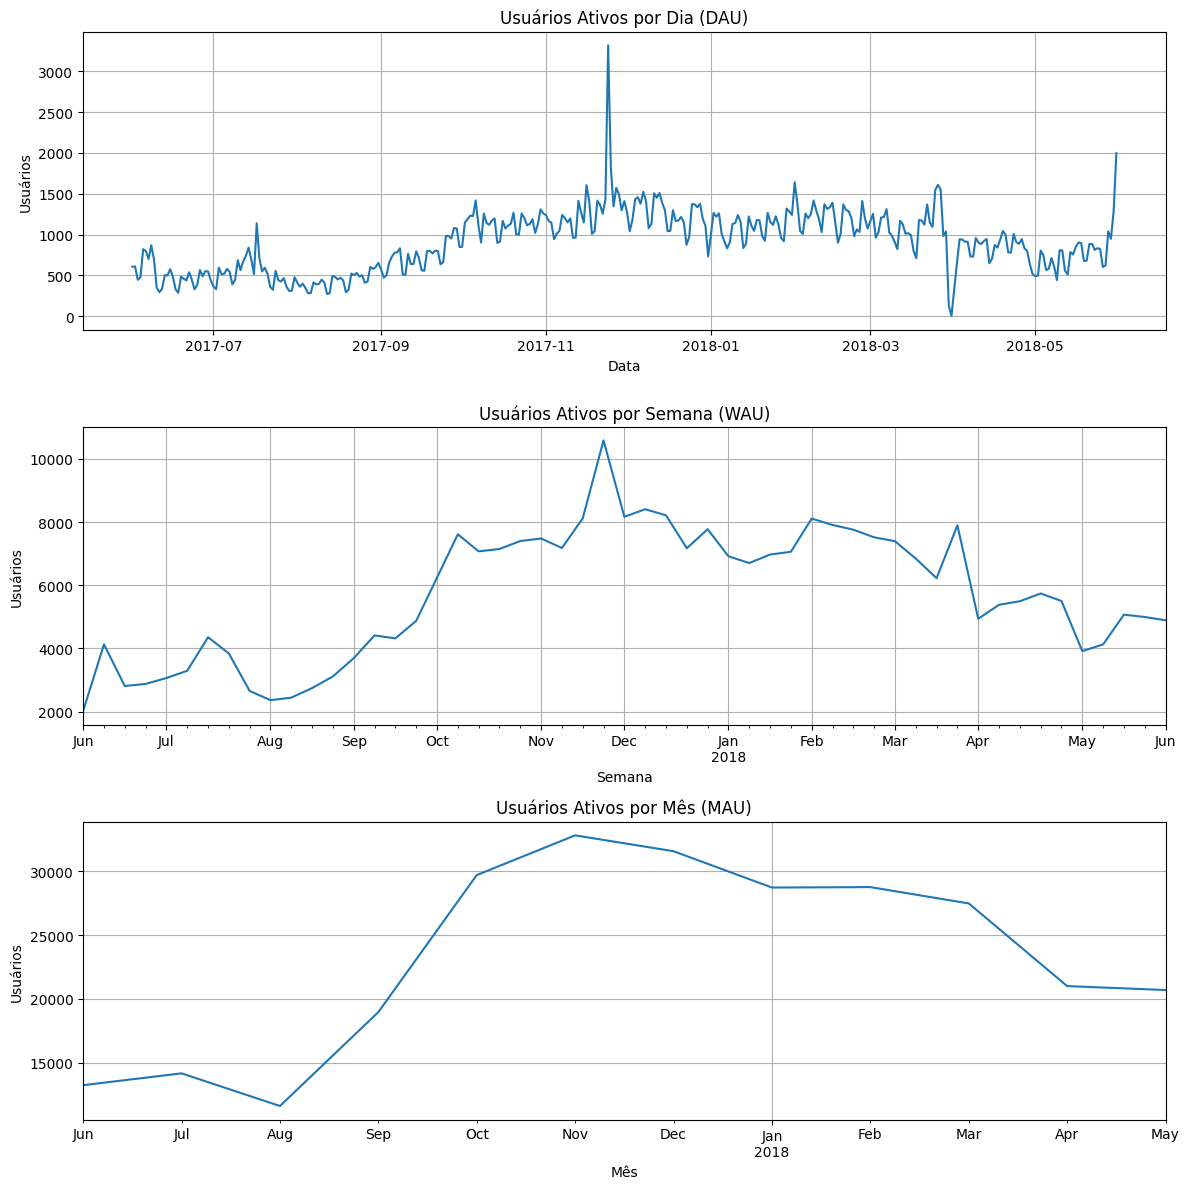

In [117]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

dau.plot(ax=axes[0])
axes[0].set_title('Usuários Ativos por Dia (DAU)')
axes[0].set_xlabel('Data'); axes[0].set_ylabel('Usuários')

wau.plot(ax=axes[1])
axes[1].set_title('Usuários Ativos por Semana (WAU)')
axes[1].set_xlabel('Semana'); axes[1].set_ylabel('Usuários')

mau.plot(ax=axes[2])
axes[2].set_title('Usuários Ativos por Mês (MAU)')
axes[2].set_xlabel('Mês'); axes[2].set_ylabel('Usuários')

plt.tight_layout()
plt.show()

Os gráficos mostram que houve crescimento de usuários até novembro, quando ocorre um pico, provavelmente ligado a alguma ação pontual. Após isso, inicia-se uma queda gradual, mais clara no mensal, indicando que a base não se sustentou. No geral, houve boa aquisição, mas baixa retenção de usuários ao longo do tempo.

Média de sessões/dia: 987


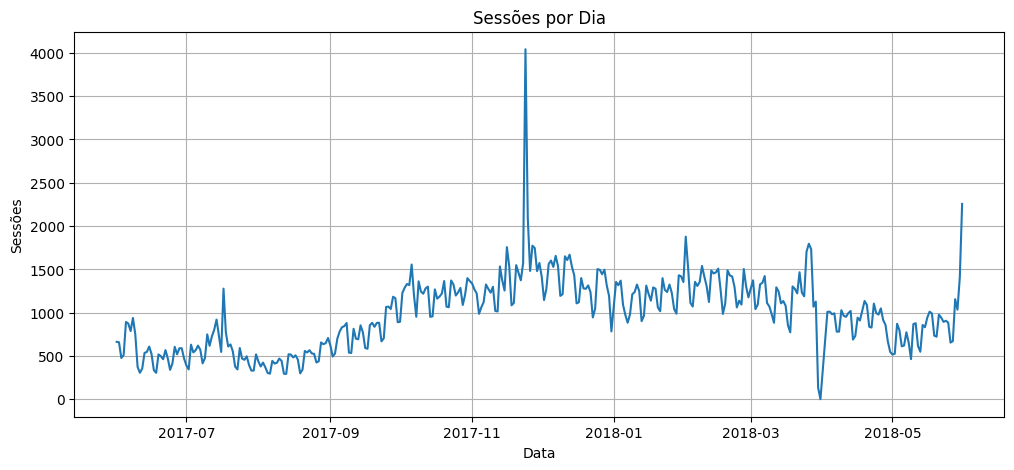

In [118]:
#Sessões por dia

sessions_per_day = visits.groupby('date')['Uid'].count()

print(f'Média de sessões/dia: {sessions_per_day.mean():.0f}')

sessions_per_day.plot(title='Sessões por Dia')
plt.xlabel('Data'); plt.ylabel('Sessões')
plt.show()

O gráfico de sessões por dia mostra um crescimento gradual até novembro, com um pico muito alto fora do padrão, indicando novamente um evento pontual. Após isso, o volume se mantém mais elevado do que no início, mas com bastante oscilação e uma leve tendência de queda ao longo do tempo. Também há uma queda brusca em um ponto específico, possivelmente erro ou indisponibilidade. No geral, apesar da média de sessões ser alta, o comportamento é instável e reforça a ideia de que houve aumento de uso sem consistência sustentável.

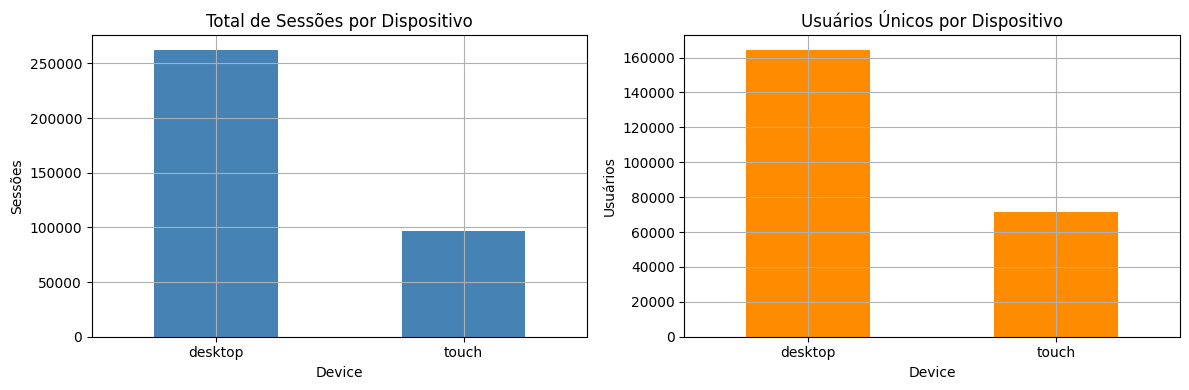

In [119]:
# Sessões por dispositivo
sessions_device = visits.groupby('Device')['Uid'].count()
users_device    = visits.groupby('Device')['Uid'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sessions_device.plot(kind='bar', ax=axes[0], title='Total de Sessões por Dispositivo', color='steelblue')
axes[0].set_ylabel('Sessões'); axes[0].tick_params(axis='x', rotation=0)

users_device.plot(kind='bar', ax=axes[1], title='Usuários Únicos por Dispositivo', color='darkorange')
axes[1].set_ylabel('Usuários'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

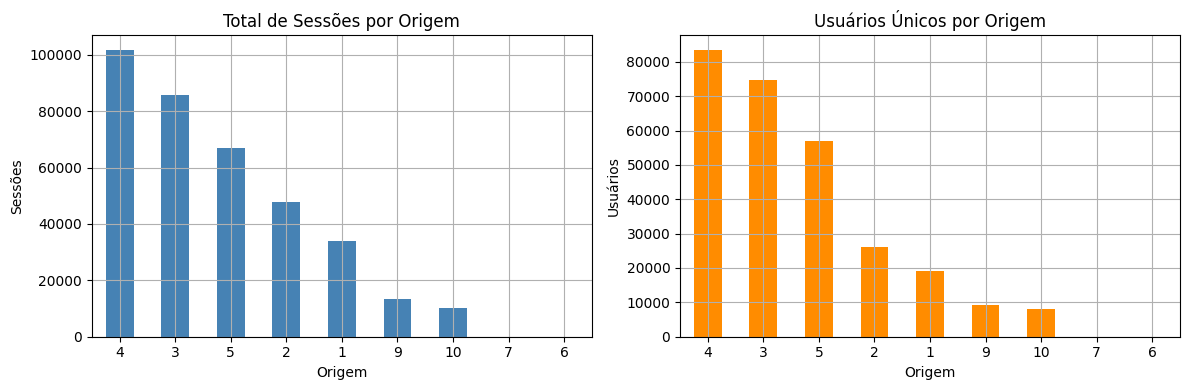

In [120]:
# Sessões e usuários por origem de anúncio
sessions_source = visits.groupby('Source Id')['Uid'].count().sort_values(ascending=False)
users_source    = visits.groupby('Source Id')['Uid'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sessions_source.plot(kind='bar', ax=axes[0], title='Total de Sessões por Origem', color='steelblue')
axes[0].set_xlabel('Origem'); axes[0].set_ylabel('Sessões'); axes[0].tick_params(axis='x', rotation=0)

users_source.plot(kind='bar', ax=axes[1], title='Usuários Únicos por Origem', color='darkorange')
axes[1].set_xlabel('Origem'); axes[1].set_ylabel('Usuários'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Os dados mostram uma clara predominância de um dispositivo específico, que concentra mais de 250 mil sessões e 160 mil usuários únicos, superando amplamente o segundo colocado. Na análise por origem, as três primeiras fontes dominam o tráfego, com a principal superando 100 mil sessões e 80 mil usuários, enquanto as demais origens apresentam uma queda progressiva e expressiva em volume, indicando que o alcance da marca está concentrado em poucos canais e em um tipo de dispositivo preferencial.

Duração média:   643 segundos (10.7 min)
Duração mediana: 300 segundos (5.0 min)
Nota: a mediana é mais representativa quando há outliers.


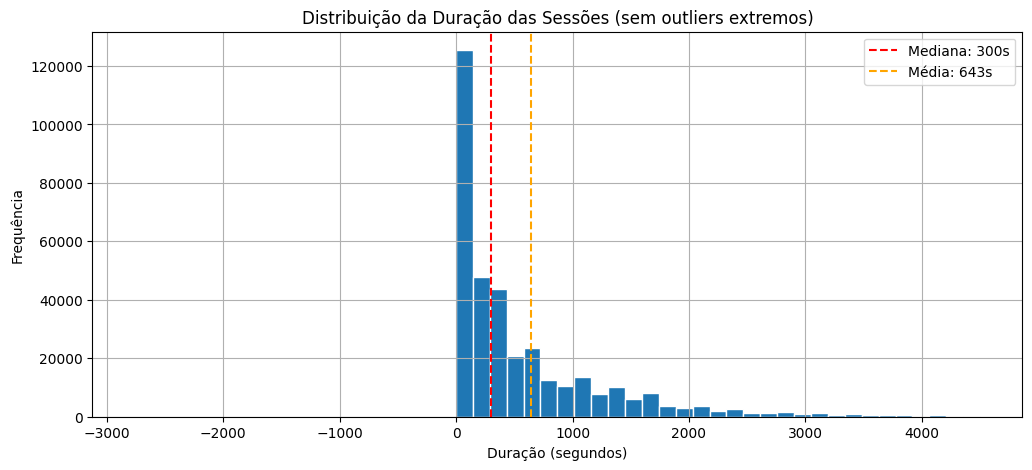

In [121]:
#Duração das Sessões
dur_media   = visits['session_duration'].mean()
dur_mediana = visits['session_duration'].median()

print(f'Duração média:   {dur_media:.0f} segundos ({dur_media/60:.1f} min)')
print(f'Duração mediana: {dur_mediana:.0f} segundos ({dur_mediana/60:.1f} min)')
print('Nota: a mediana é mais representativa quando há outliers.')

# Remover outliers extremos para melhor visualização (99º percentil)
limite = visits['session_duration'].quantile(0.99)
visits_clean = visits[visits['session_duration'] <= limite]

plt.hist(visits_clean['session_duration'], bins=50, edgecolor='white')
plt.axvline(dur_mediana, color='red',    linestyle='--', label=f'Mediana: {dur_mediana:.0f}s')
plt.axvline(dur_media,   color='orange', linestyle='--', label=f'Média: {dur_media:.0f}s')
plt.title('Distribuição da Duração das Sessões (sem outliers extremos)')
plt.xlabel('Duração (segundos)'); plt.ylabel('Frequência')
plt.legend()
plt.show()

A distribuição da duração das sessões mostra que a maioria dos usuários permanece pouco tempo, com concentração forte em durações mais baixas. A mediana é de 5 minutos, enquanto a média é maior, cerca de 10,7 minutos, o que indica a presença de sessões longas que puxam a média para cima. Isso revela que poucos usuários são altamente engajados, enquanto a maior parte tem interações curtas. No geral, o comportamento é assimétrico e reforça que o engajamento não é consistente para a maioria da base.

Média de sessões por usuário: 1.58
Usuários com mais de 1 sessão: 22.8%


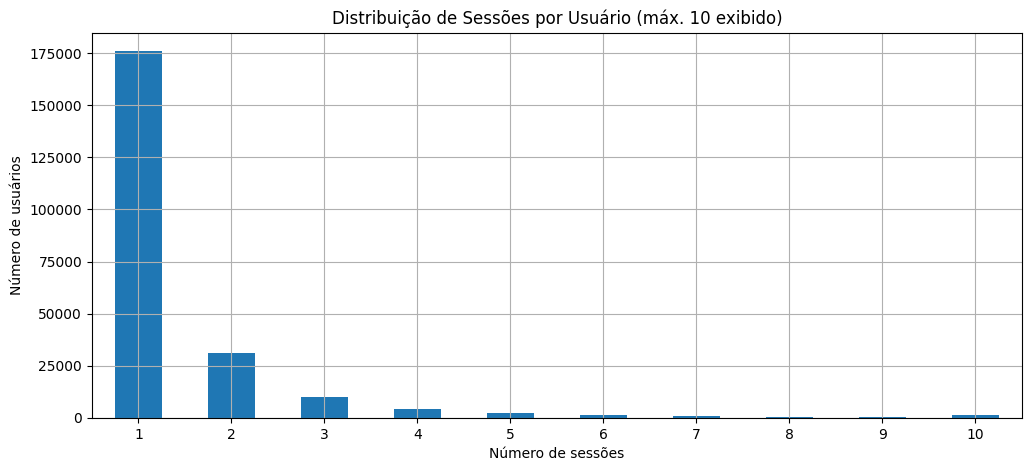

In [122]:
#Frequência de Retorno dos Usuários
sessions_per_user = visits.groupby('Uid').size()

print(f'Média de sessões por usuário: {sessions_per_user.mean():.2f}')
print(f'Usuários com mais de 1 sessão: {(sessions_per_user > 1).mean()*100:.1f}%')

# Distribuição do número de sessões por usuário (até 10 para legibilidade)
sessions_per_user.clip(upper=10).value_counts().sort_index().plot(
    kind='bar', title='Distribuição de Sessões por Usuário (máx. 10 exibido)')
plt.xlabel('Número de sessões'); plt.ylabel('Número de usuários')
plt.xticks(rotation=0)
plt.show()


A distribuição de sessões por usuário mostra que a grande maioria dos usuários acessa apenas uma vez, com média de 1,58 sessões por pessoa e apenas 22,8% retornando para uma segunda sessão ou mais. Isso indica um nível baixo de recorrência, onde poucos usuários voltam a utilizar o produto. No geral, o comportamento reforça um problema claro de retenção, com dificuldade em transformar novos usuários em usuários recorrentes.


<div class="alert alert-block alert-danger">
<b> Comentário do revisor v1: </b> <a class="tocSkip"></a>

- Convém separar por coorte

</div>


<div class="alert alert-block alert-info">
<b>Okay, inclui logo abaixo do seu exemplo.</b> <a class="tocSkip"></a>
</div>


<div class="alert alert-block alert-success">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

Correto
</div>


In [123]:
# # --- Com que frequência os usuários voltam?  

# # Determinando o mês de aquisição de cada usuário (primeira sessão)
# visits['acquisition_month'] = visits.groupby('uid')['start_ts'].transform('min').dt.to_period('M')


# visits['session_month'] = visits['start_ts'].dt.to_period('M')

# # Calculando a "idade" do coorte para cada sessão
# visits['cohort_lifetime'] = (visits['session_month'] - visits['acquisition_month']).apply(lambda x: x.n)

# # Tabela de coortes (pivot table)
# cohorts = visits.groupby(['acquisition_month', 'cohort_lifetime'])['uid'].nunique().reset_index()
# cohorts_pivot = cohorts.pivot_table(index='acquisition_month', columns='cohort_lifetime', values='uid')

# # Calculando a retenção em percentual
# cohort_size = cohorts_pivot.iloc[:, 0]
# retention_matrix = cohorts_pivot.divide(cohort_size, axis=0)

# # Gerando o mapa de calor de retenção
# ## PLOTE AQUI O HEATMAP

# Visão geral rápida
sessions_per_user = visits.groupby('Uid').size()
print(f'Média de sessões por usuário: {sessions_per_user.mean():.2f}')
print(f'Usuários com mais de 1 sessão: {(sessions_per_user > 1).mean()*100:.1f}%')



Média de sessões por usuário: 1.58
Usuários com mais de 1 sessão: 22.8%


In [124]:
# Mês de aquisição e mês da sessão 
visits['acquisition_month'] = visits['first_visit_ts'].dt.to_period('M')
visits['session_month']     = visits['Start Ts'].dt.to_period('M')

# Idade do coorte: quantos meses depois da aquisição o usuário voltou
visits['cohort_lifetime'] = (
    visits['session_month'] - visits['acquisition_month']
).apply(lambda x: x.n)

# Número de usuários únicos por coorte e por mês de vida
cohorts = (
    visits
    .groupby(['acquisition_month', 'cohort_lifetime'])['Uid']
    .nunique()
    .reset_index()
)

# Pivot: linhas = coorte, colunas = mês de vida 
cohorts_pivot = cohorts.pivot_table(
    index='acquisition_month',
    columns='cohort_lifetime',
    values='Uid'
)

# Tamanho de cada coorte (mês 0 = todos os novos usuários do mês)
cohort_size = cohorts_pivot[0]

# Matriz de retenção em % relativa ao tamanho original da coorte
retention_matrix = cohorts_pivot.divide(cohort_size, axis=0).round(3)

print('Tamanho de cada coorte (usuários novos por mês):')
print(cohort_size)

Tamanho de cada coorte (usuários novos por mês):
acquisition_month
2017-06    13259.0
2017-07    13140.0
2017-08    10181.0
2017-09    16704.0
2017-10    25977.0
2017-11    27248.0
2017-12    25268.0
2018-01    22624.0
2018-02    22197.0
2018-03    20589.0
2018-04    15709.0
2018-05    15273.0
Freq: M, Name: 0, dtype: float64


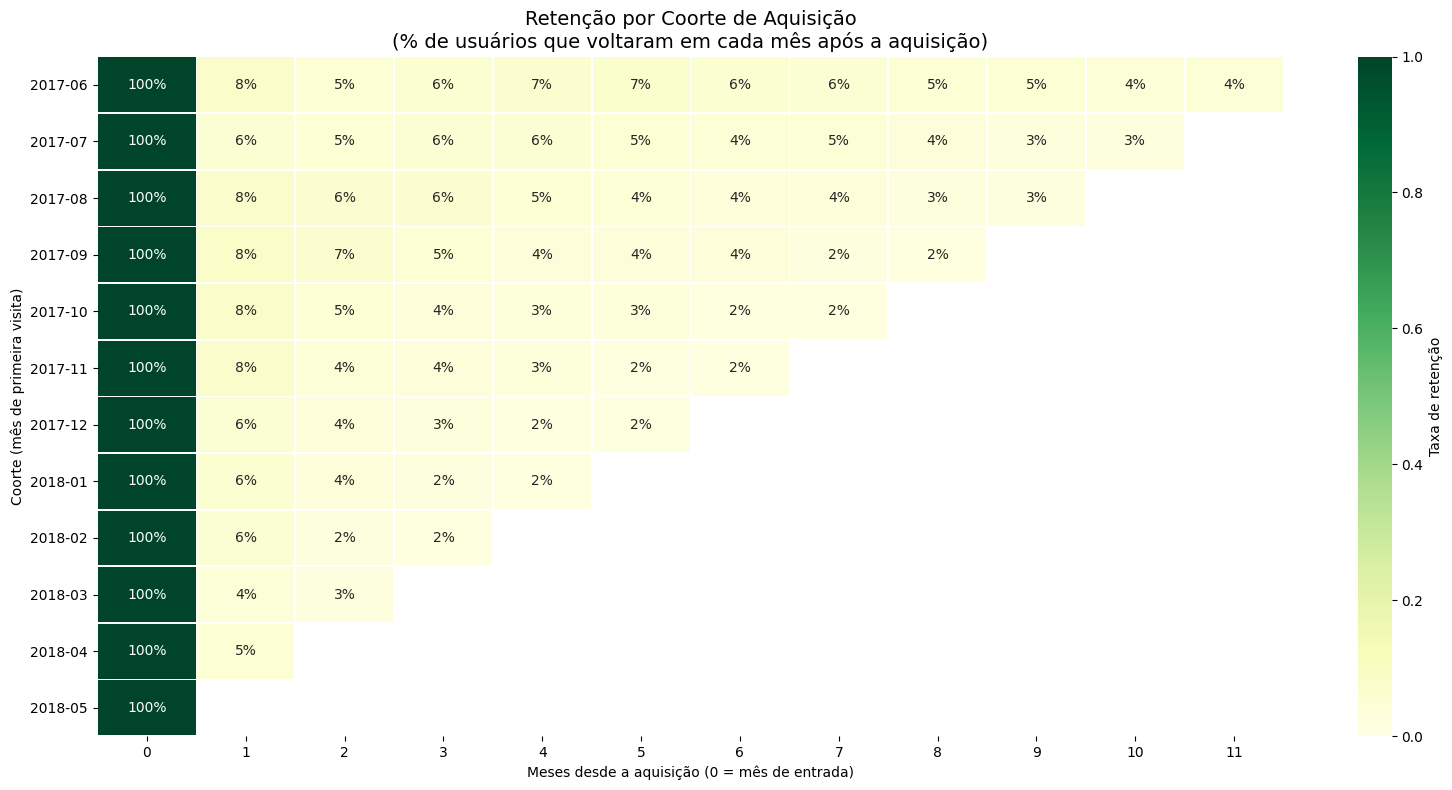

In [125]:
#Heatmap de Retenção por Coorte
fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.0%',
    cmap='YlGn',
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Taxa de retenção'}
)

ax.set_title('Retenção por Coorte de Aquisição\n(% de usuários que voltaram em cada mês após a aquisição)', fontsize=14)
ax.set_xlabel('Meses desde a aquisição (0 = mês de entrada)')
ax.set_ylabel('Coorte (mês de primeira visita)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

O negócio atrai muitos visitantes, mas falha em retê-los, resultando em um custo de aquisição que não se paga no longo prazo. O foco deve ser priorizar investimentos nas Origens 1 e 2 e no uso de Desktop, que são os únicos segmentos lucrativos. Para reverter o prejuízo, é urgente reduzir os gastos na ineficiente Origem 3 e criar estratégias para aumentar a fidelidade dos clientes após a primeira compra.

In [126]:
first_order = orders.groupby('Uid')['Buy Ts'].min().rename('first_order_ts')

conversion = first_visit.to_frame().merge(first_order.to_frame(), on='Uid')
conversion['conversion_days'] = (conversion['first_order_ts'] - conversion['first_visit_ts']).dt.days

print('Distribuição dos dias até conversão:')
print(conversion['conversion_days'].describe())
print(f"\nCompras no mesmo dia (dia 0): {(conversion['conversion_days'] == 0).mean()*100:.1f}%")
print(f"Compras em até 7 dias:         {(conversion['conversion_days'] <= 7).mean()*100:.1f}%")
print(f"Compras em até 30 dias:        {(conversion['conversion_days'] <= 30).mean()*100:.1f}%")

Distribuição dos dias até conversão:
count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: conversion_days, dtype: float64

Compras no mesmo dia (dia 0): 72.2%
Compras em até 7 dias:         80.6%
Compras em até 30 dias:        86.6%


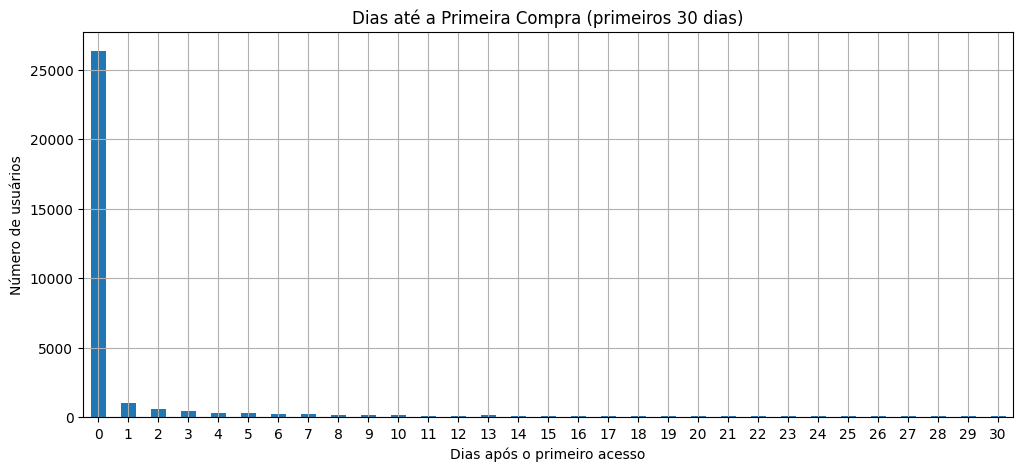

In [127]:
# Mostrar apenas os primeiros 30 dias (mais relevante)
conv_30 = conversion[conversion['conversion_days'] <= 30]
conv_30['conversion_days'].value_counts().sort_index().plot(
    kind='bar', title='Dias até a Primeira Compra (primeiros 30 dias)')
plt.xlabel('Dias após o primeiro acesso'); plt.ylabel('Número de usuários')
plt.xticks(rotation=0)
plt.show()

O gráfico mostra que a grande maioria das compras acontece no mesmo dia do primeiro acesso, com uma queda muito acentuada já a partir do dia seguinte. Pouquíssimos usuários convertem após os primeiros dias, e quase não há compras ao longo do restante dos 30 dias. Isso indica que a conversão está extremamente concentrada no início da jornada, e que o produto tem dificuldade em engajar e converter usuários ao longo do tempo, reforçando um problema tanto de retenção quanto de maturação da base.

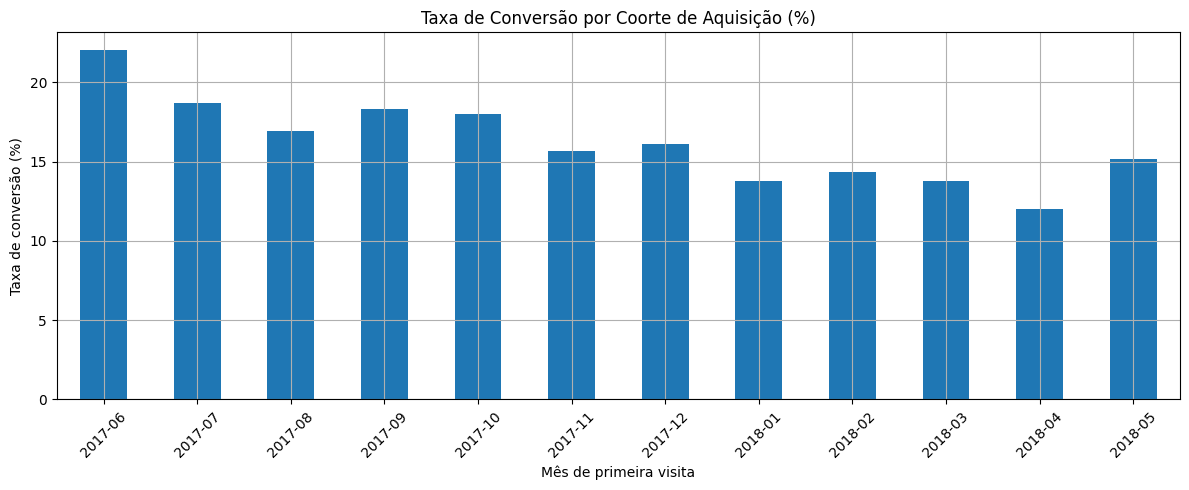

first_visit_month
2017-06    22.0
2017-07    18.7
2017-08    16.9
2017-09    18.3
2017-10    18.0
2017-11    15.6
2017-12    16.1
2018-01    13.8
2018-02    14.4
2018-03    13.8
2018-04    12.0
2018-05    15.2
Freq: M, Name: converted, dtype: float64


In [128]:
# Tabela de usuários únicos com seu mês de primeira visita
user_cohort = visits[['Uid','first_visit_month']].drop_duplicates()

# Marca quais usuários fizeram ao menos 1 pedido
buyers = orders['Uid'].unique()
user_cohort['converted'] = user_cohort['Uid'].isin(buyers)

conversion_rate = user_cohort.groupby('first_visit_month')['converted'].mean() * 100

conversion_rate.plot(kind='bar', title='Taxa de Conversão por Coorte de Aquisição (%)')
plt.xlabel('Mês de primeira visita'); plt.ylabel('Taxa de conversão (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(conversion_rate.round(1))

O gráfico mostra que a taxa de conversão de novos usuários caiu ao longo de um ano, passando de 22% (junho/17) para 15,2% (maio/18).

O desempenho atingiu seu ponto mais baixo em abril de 2018 (12%), indicando uma perda gradual de eficiência na aquisição de clientes, com uma leve recuperação no último mês registrado.

In [129]:
#Pedidos por Cliente e Ticket Médio
orders_per_user = orders.groupby('Uid').size()
ticket_medio    = orders['Revenue'].mean()

print(f'Média de pedidos por cliente: {orders_per_user.mean():.2f}')
print(f'Ticket médio por pedido: ${ticket_medio:.2f}')

Média de pedidos por cliente: 1.38
Ticket médio por pedido: $5.00


In [130]:
#LTV — Receita por Cliente ao Longo do Tempo
ltv_por_usuario = orders.groupby('Uid')['Revenue'].sum()
print(f'LTV médio por usuário: ${ltv_por_usuario.mean():.2f}')
print(f'LTV mediano:           ${ltv_por_usuario.median():.2f}')

LTV médio por usuário: $6.90
LTV mediano:           $3.05


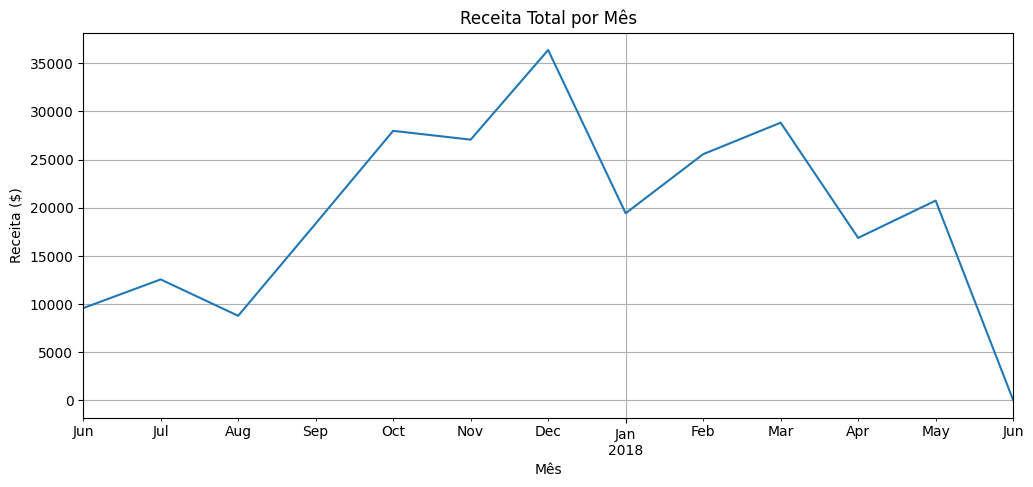

In [131]:
# Receita total por mês
orders['order_month'] = orders['Buy Ts'].dt.to_period('M')
receita_mensal = orders.groupby('order_month')['Revenue'].sum()

receita_mensal.plot(title='Receita Total por Mês')
plt.xlabel('Mês'); plt.ylabel('Receita ($)')
plt.show()

É possivel ver um crescimento expressivo ao longo de 2017, atingindo seu pico máximo acima de $35.000 em dezembro. No entanto, o primeiro semestre de 2018 revela forte instabilidade, com uma queda acentuada em janeiro e um declínio final severo em junho, indicando que o faturamento não conseguiu sustentar o patamar alcançado no fim do ano anterior.

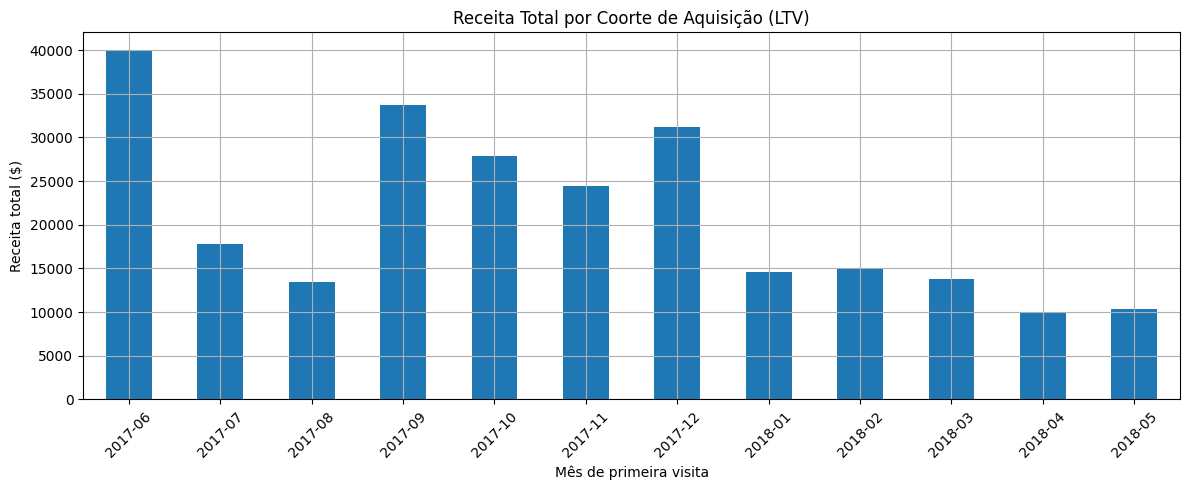

In [132]:
# LTV acumulado por coorte de aquisição
orders_cohort = orders.merge(
    visits[['Uid','first_visit_month']].drop_duplicates(), on='Uid', how='left'
)

ltv_cohort = orders_cohort.groupby('first_visit_month')['Revenue'].sum()
ltv_cohort.plot(kind='bar', title='Receita Total por Coorte de Aquisição (LTV)')
plt.xlabel('Mês de primeira visita'); plt.ylabel('Receita total ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

É possiver notar que os clientes adquiridos em junho de 2017 foram os mais valiosos, gerando o pico de faturamento de 40.000 reais. Embora existam recuperações pontuais em setembro e dezembro de 2017, a tendência geral é de declínio, com as coortes de 2018 gerando receitas significativamente menores, estabilizadas abaixo de 15.000 reais. Isso indica que os grupos de novos usuários mais recentes estão trazendo um retorno financeiro total muito inferior aos grupos do início do período.


<div class="alert alert-block alert-danger">
<b> Comentário do revisor v1: </b> <a class="tocSkip"></a>

- Vocẽ removeu o aspecto temporal. Deixo dica abaixo

</div>

<div class="alert alert-block alert-info">
<b>Entendi, dessa forma é muito mais facil de se visualizar o LTV de uma forma mais segmentada, anotado</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-success">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

Correto
</div>


In [133]:

# # --- Quanto dinheiro eles trazem para a empresa (LTV)?


# # Definindo o mês de aquisição (primeira compra) como o coorte
# orders['acquisition_month'] = orders.groupby('uid')['buy_ts'].transform('min').dt.to_period('M')

# # Calculando a idade do coorte para cada pedido
# orders['cohort_lifetime'] = ((orders['order_month'] - orders['acquisition_month']).apply(lambda x: x.n))

# # Calculando a receita por coorte e por idade
# cohorts_revenue = orders.groupby(['acquisition_month', 'cohort_lifetime'])['revenue'].sum().reset_index()

# # Obtendo o tamanho de cada coorte (número de clientes únicos)
# cohort_sizes = orders.groupby('acquisition_month')['uid'].nunique().reset_index()
# cohort_sizes.columns = ['acquisition_month', 'n_buyers']

# # Unindo os dados de receita e tamanho do coorte
# cohorts_data = pd.merge(cohorts_revenue, cohort_sizes, on='acquisition_month')

# # LTV
# cohorts_data['ltv'] = cohorts_data['revenue'] / cohorts_data['n_buyers']

# # Tabela pivot para o LTV
# ltv_pivot = cohorts_data.pivot_table(index='acquisition_month',
#                                      columns='cohort_lifetime',
#                                      values='ltv',
#                                      aggfunc='sum').cumsum(axis=1)

# # Heatmap do LTV
# ## PLOTE AQUI O HEATMAP


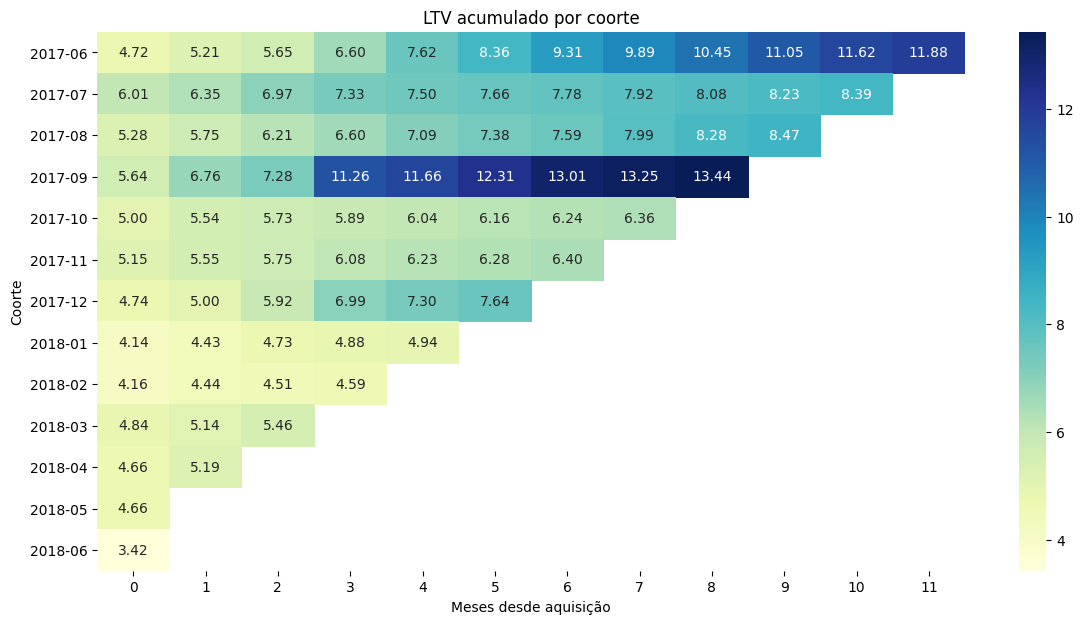

In [134]:
# Definir mês da primeira compra (coorte)
orders['acquisition_month'] = orders.groupby('Uid')['Buy Ts'].transform('min').dt.to_period('M')

# Mês do pedido
orders['order_month'] = orders['Buy Ts'].dt.to_period('M')

# Tempo desde aquisição
orders['cohort_lifetime'] = (
    orders['order_month'] - orders['acquisition_month']
).apply(lambda x: x.n)

# Receita por coorte e tempo
cohorts_revenue = (
    orders.groupby(['acquisition_month', 'cohort_lifetime'])['Revenue']
    .sum()
    .reset_index()
)

# Tamanho do coorte
cohort_sizes = (
    orders.groupby('acquisition_month')['Uid']
    .nunique()
    .reset_index()
)
cohort_sizes.columns = ['acquisition_month', 'n_buyers']

# Merge
cohorts_data = cohorts_revenue.merge(cohort_sizes, on='acquisition_month')

# LTV
cohorts_data['ltv'] = cohorts_data['Revenue'] / cohorts_data['n_buyers']

# Pivot + acumulado
ltv_pivot = cohorts_data.pivot_table(
    index='acquisition_month',
    columns='cohort_lifetime',
    values='ltv'
).cumsum(axis=1)

# Heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(ltv_pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('LTV acumulado por coorte')
plt.xlabel('Meses desde aquisição')
plt.ylabel('Coorte')
plt.show()

O LTV por coorte mostra que a maior parte da receita é gerada nos primeiros meses após a aquisição, com crescimento muito lento ao longo do tempo. As coortes mais antigas apresentam desempenho superior, enquanto as mais recentes geram menos valor, reforçando a tendência de queda na qualidade dos usuários adquiridos.

In [135]:
#Métricas de Vendas por Dispositivo e por Origem
# Adicionar Device e Source Id aos pedidos via tabela de visitas 
user_device_source = (
    visits.sort_values('Start Ts')
    .groupby('Uid')[['Device', 'Source Id']]
    .first()
    .reset_index()
)

orders_enriched = orders.merge(user_device_source, on='Uid', how='left')

# --- Ticket médio por dispositivo ---
ticket_device = orders_enriched.groupby('Device')['Revenue'].mean()
print('Ticket médio por dispositivo:')
print(ticket_device.round(2))

# --- LTV por dispositivo ---
ltv_device = orders_enriched.groupby(['Uid','Device'])['Revenue'].sum().reset_index()
ltv_device = ltv_device.groupby('Device')['Revenue'].mean()
print('\nLTV médio por dispositivo:')
print(ltv_device.round(2))

Ticket médio por dispositivo:
Device
desktop    5.16
touch      4.29
Name: Revenue, dtype: float64

LTV médio por dispositivo:
Device
desktop    7.23
touch      5.57
Name: Revenue, dtype: float64


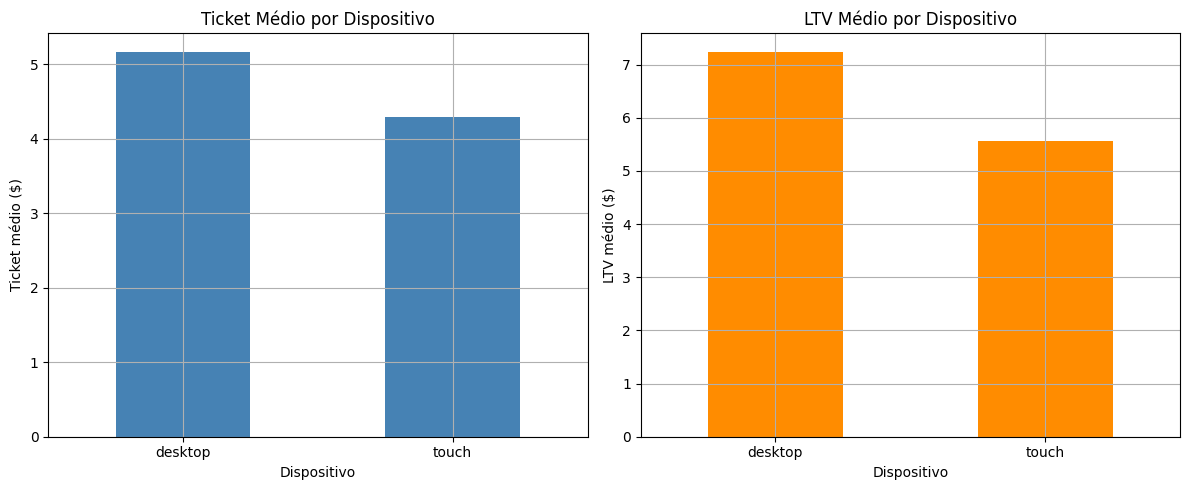

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ticket_device.plot(kind='bar', ax=axes[0], title='Ticket Médio por Dispositivo', color='steelblue')
axes[0].set_xlabel('Dispositivo'); axes[0].set_ylabel('Ticket médio ($)')
axes[0].tick_params(axis='x', rotation=0)

ltv_device.plot(kind='bar', ax=axes[1], title='LTV Médio por Dispositivo', color='darkorange')
axes[1].set_xlabel('Dispositivo'); axes[1].set_ylabel('LTV médio ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

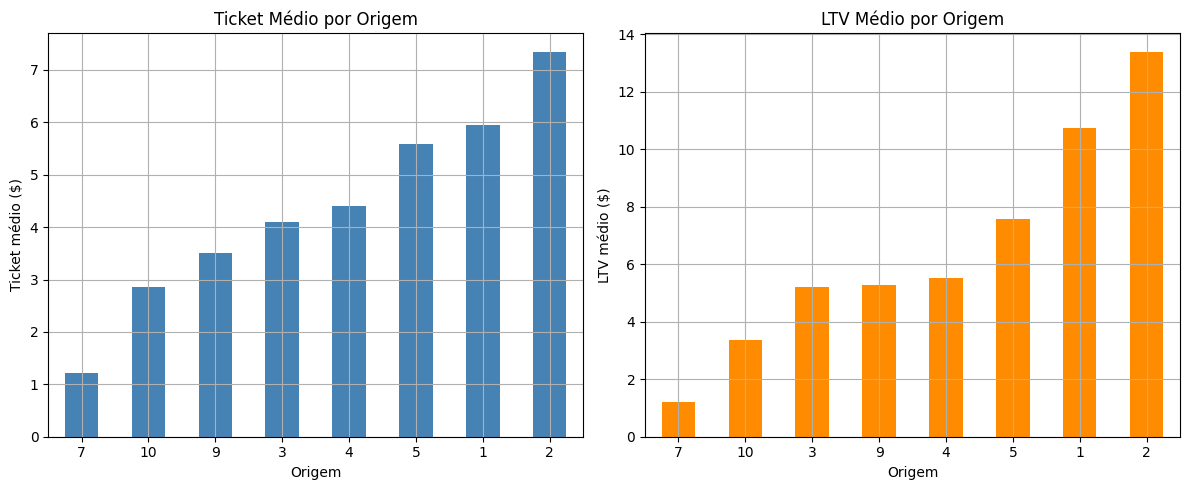

Ticket médio por origem:
Source Id
1     5.95
2     7.34
3     4.10
4     4.40
5     5.59
7     1.22
9     3.50
10    2.85
Name: Revenue, dtype: float64

LTV médio por origem:
Source Id
1     10.72
2     13.38
3      5.20
4      5.51
5      7.59
7      1.22
9      5.29
10     3.35
Name: Revenue, dtype: float64


In [137]:
#Ticket médio por origem
ticket_source = orders_enriched.groupby('Source Id')['Revenue'].mean()

#LTV por origem
ltv_source = orders_enriched.groupby(['Uid','Source Id'])['Revenue'].sum().reset_index()
ltv_source = ltv_source.groupby('Source Id')['Revenue'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ticket_source.sort_values().plot(kind='bar', ax=axes[0], title='Ticket Médio por Origem', color='steelblue')
axes[0].set_xlabel('Origem'); axes[0].set_ylabel('Ticket médio ($)')
axes[0].tick_params(axis='x', rotation=0)

ltv_source.sort_values().plot(kind='bar', ax=axes[1], title='LTV Médio por Origem', color='darkorange')
axes[1].set_xlabel('Origem'); axes[1].set_ylabel('LTV médio ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('Ticket médio por origem:'); print(ticket_source.round(2))
print('\nLTV médio por origem:');   print(ltv_source.round(2))

Os gráficos mostram que o desktop supera os dispositivos móveis em ticket médio e LTV, sendo a plataforma mais lucrativa. Na análise por canais, as origens 2 e 1 entregam o maior valor financeiro por cliente, enquanto a origem 7 apresenta o menor retorno em todas as métricas de receita.

In [138]:
#Gastos Totais com Marketing
gasto_total = costs['costs'].sum()
print(f'Gasto total com marketing: ${gasto_total:,.2f}')

Gasto total com marketing: $329,131.62


Observamos uma concentração massiva de investimentos na Origem 3, que domina o orçamento com mais de 140.000 reais em gastos. As demais fontes apresentam valores significativamente menores, com as origens 4, 5 e 2 variando entre 40.000 e 60.000 reais, enquanto as origens 1, 10 e 9 recebem investimentos mínimos, todos abaixo de $25.000. Essa disparidade indica uma estratégia de marketing fortemente dependente de um único canal principal.


<div class="alert alert-block alert-danger">
<b> Comentário do revisor v1: </b> <a class="tocSkip"></a>

- Convém avaliar temporalemnte. Deixo dica

</div>

<div class="alert alert-block alert-info">
<b>Consegui visualizar a necessiade, obrigada</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-success">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

Correto
</div>


In [139]:
# # --- Quanto dinheiro foi gasto?



# # Adicionando uma coluna de mês para agrupar os custos
# costs['month'] = costs['dt'].dt.to_period('M')

# # Criar uma tabela dinâmica (pivot) para organizar os dados para o gráfico
# # Onde o índice é o mês, as colunas são as fontes e os valores são os custos
# costs_pivot = costs.pivot_table(
#     index='month',
#     columns='source_id',
#     values='costs',
#     aggfunc='sum'
# ).fillna(0)

# # Plotando o gráfico de linhas a partir da tabela dinâmica
# ## PLOTE AQUI O GRÁFICO LINHA

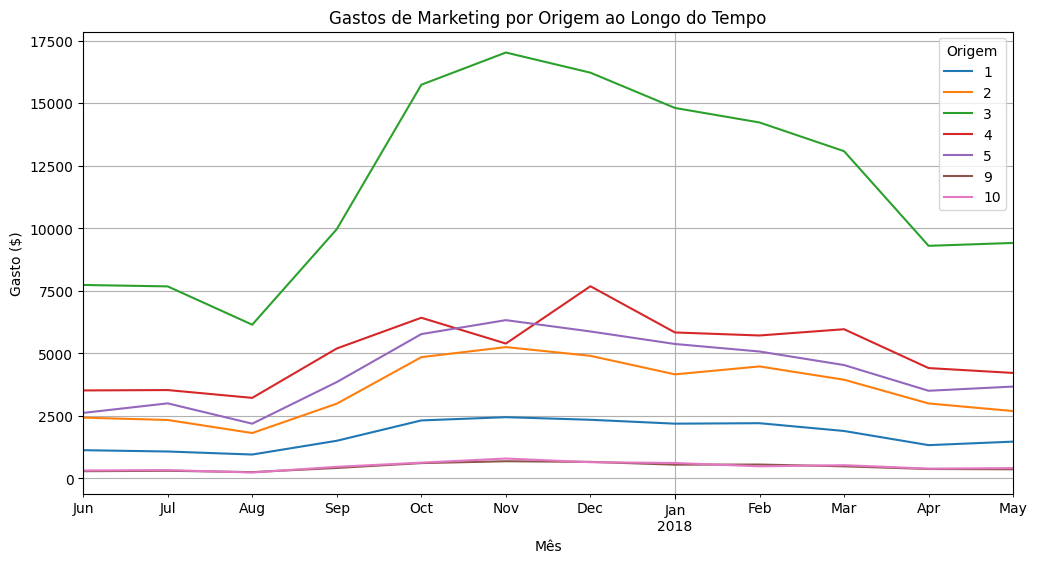

In [145]:
#Calculando custos agrupados
costs['month'] = costs['dt'].dt.to_period('M')

costs_pivot = costs.pivot_table(
    index='month',
    columns='source_id',
    values='costs',
    aggfunc='sum'
).fillna(0)

costs_pivot.plot(figsize=(12,6))
plt.title('Gastos de Marketing por Origem ao Longo do Tempo')
plt.xlabel('Mês')
plt.ylabel('Gasto ($)')
plt.legend(title='Origem')
plt.show()

Ao analisar os custos ao longo do tempo, é possível observar que a Origem 3 concentra investimentos de forma consistente durante todo o período, enquanto as demais fontes apresentam menor volume e maior estabilidade. Isso reforça a dependência excessiva de um único canal.

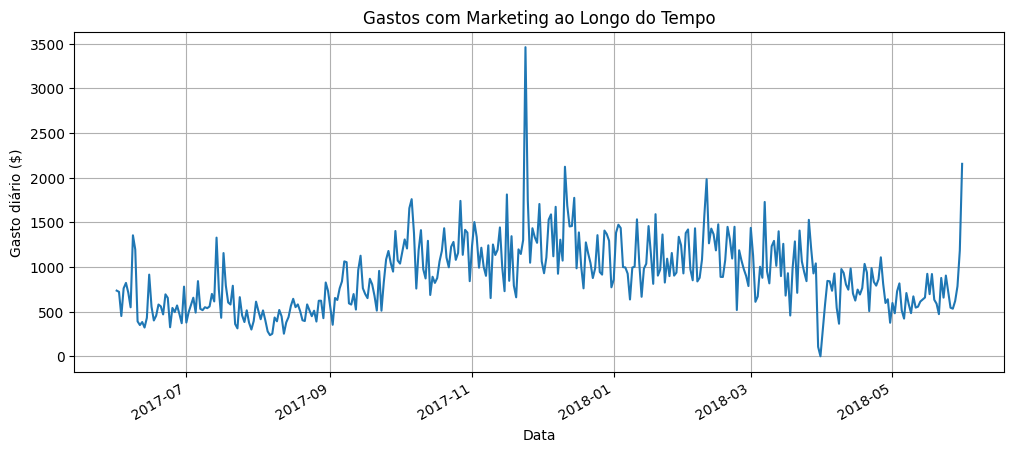

In [140]:
#Gastos ao Longo do Tempo
costs.groupby('dt')['costs'].sum().plot(title='Gastos com Marketing ao Longo do Tempo')
plt.xlabel('Data'); plt.ylabel('Gasto diário ($)')
plt.show()


Percebemos um investimento diário que oscila majoritariamente entre 500 e 1500 reais , com um aumento gradual de volume no segundo semestre de 2017. O dado mais relevante é um pico isolado e atípico em dezembro de 2017, onde o gasto saltou para quase 3500 reais em um único dia, seguido por uma fase de maior instabilidade e picos frequentes no início de 2018 até uma queda brusca e posterior recuperação em maio.

CAC por origem:
3     13.49
2     12.21
5      7.47
1      7.19
4      5.93
9      5.07
10     4.38
dtype: float64


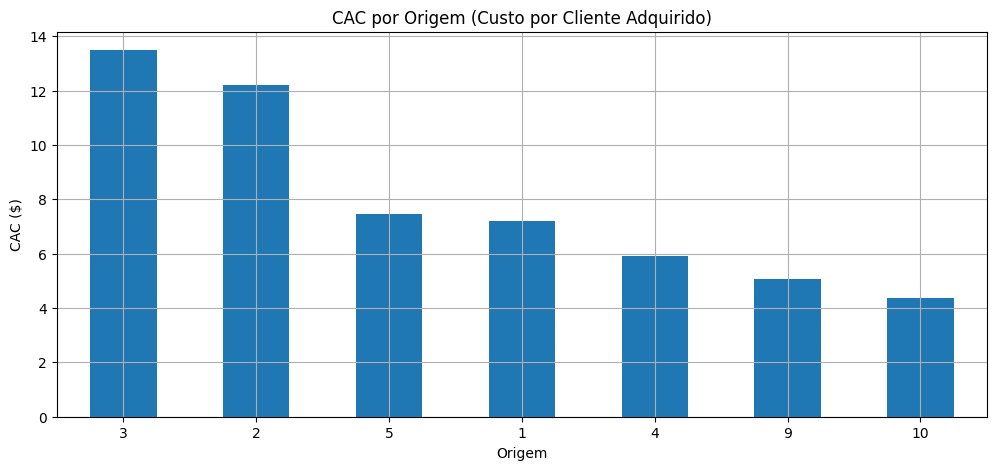

In [141]:
#CAC — Custo de Aquisição por Cliente
# Clientes que realizaram pelo menos 1 pedido
customers = orders['Uid'].unique()
visits_customers = visits[visits['Uid'].isin(customers)]

# Clientes por origem (canal que os trouxe na primeira visita)
first_visit_source = (
    visits_customers
    .sort_values('Start Ts')
    .groupby('Uid')['Source Id']
    .first()
    .reset_index()
)
customers_per_source = first_visit_source.groupby('Source Id')['Uid'].nunique()
customers_per_source.index = customers_per_source.index.astype(str)
cost_per_source.index      = cost_per_source.index.astype(str)

cac = cost_per_source / customers_per_source
cac = cac.dropna().sort_values(ascending=False)

print('CAC por origem:')
print(cac.round(2))

cac.plot(kind='bar', title='CAC por Origem (Custo por Cliente Adquirido)')
plt.xlabel('Origem'); plt.ylabel('CAC ($)')
plt.xticks(rotation=0)
plt.show()


Podemos ver que as fontes 3 e 2 são as mais caras para a aquisição de clientes, com custos superiores a 12 reais. Em contrapartida, as origens 9 e 10 apresentam a melhor eficiência de custo, mantendo o CAC abaixo de 6 reais. As demais fontes (5, 1 e 4) possuem um custo intermediário entre 6 reais e 8 reais, indicando que há uma variação de mais de 100% no custo de aquisição dependendo do canal escolhido.


<div class="alert alert-block alert-danger">
<b> Comentário do revisor v1: </b> <a class="tocSkip"></a>

- Convém considerar o aspecto temporal. Deixo dica

</div>

<div class="alert alert-block alert-success">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

Correto
</div>


In [142]:

# # --- Quanto custou a aquisição de clientes (CAC)?


# # Adiciando uma coluna de mês aos custos
# costs['month'] = costs['dt'].dt.to_period('M')

# # Encontrando a primeira visita de cada usuário para obter a fonte de aquisição
# first_visits = visits.sort_values('start_ts').drop_duplicates('uid')
# first_visits = first_visits[['uid', 'source_id']]

# # Encontrando o mês da primeira compra de cada cliente
# first_orders = orders.sort_values('buy_ts').drop_duplicates('uid')
# first_orders['acquisition_month'] = first_orders['buy_ts'].dt.to_period('M')
# first_orders = first_orders[['uid', 'acquisition_month']]

# # Unindo as informações para saber a fonte e o mês de aquisição de cada cliente
# buyers = pd.merge(first_orders, first_visits, on='uid')

# # Calculando o número de clientes adquiridos por mês e por fonte
# buyers_by_month_source = buyers.groupby(['acquisition_month', 'source_id'])['uid'].nunique().reset_index()
# buyers_by_month_source.columns = ['month', 'source_id', 'n_buyers']

# # Formanto os custos mensais por fonte
# costs_by_month_source = costs.groupby(['month', 'source_id'])['costs'].sum().reset_index()

# # Unindo custos e número de compradores por mês e fonte
# cac_monthly_data = pd.merge(costs_by_month_source, buyers_by_month_source, on=['month', 'source_id'])

# # CAC mensal para cada fonte
# # (Lidar com a divisão por zero caso haja custos sem compradores, embora improvável com o merge)
# cac_monthly_data = cac_monthly_data[cac_monthly_data['n_buyers'] > 0]
# cac_monthly_data['cac'] = cac_monthly_data['costs'] / cac_monthly_data['n_buyers']

# # Tabela dinâmica (pivot) para a plotagem
# cac_pivot = cac_monthly_data.pivot_table(
#     index='month',
#     columns='source_id',
#     values='cac'
# )

# # Gráfico de linhas
# ## PLOTE AQUI O GRÁFICO LINHA


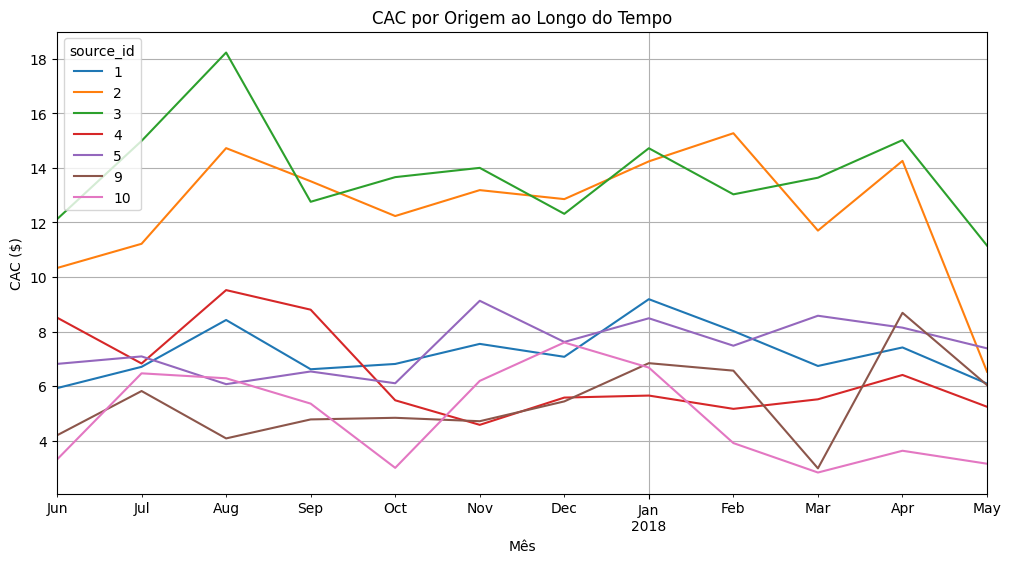

In [146]:
# Mês nos custos
costs['month'] = costs['dt'].dt.to_period('M')

# Primeira compra
first_orders = orders.sort_values('Buy Ts').drop_duplicates('Uid')
first_orders['acquisition_month'] = first_orders['Buy Ts'].dt.to_period('M')

# Primeira visita (fonte)
first_visits = visits.sort_values('Start Ts').drop_duplicates('Uid')
first_visits = first_visits[['Uid', 'Source Id']]

# Merge
buyers = first_orders.merge(first_visits, on='Uid')

# Clientes por mês e origem
buyers_by_month = buyers.groupby(['acquisition_month', 'Source Id'])['Uid'].nunique().reset_index()
buyers_by_month.columns = ['month', 'source_id', 'n_buyers']

# Custos
costs_by_month = costs.groupby(['month', 'source_id'])['costs'].sum().reset_index()

# Merge
cac_data = costs_by_month.merge(buyers_by_month, on=['month', 'source_id'])

# CAC
cac_data = cac_data[cac_data['n_buyers'] > 0]
cac_data['cac'] = cac_data['costs'] / cac_data['n_buyers']

# Pivot
cac_pivot = cac_data.pivot_table(
    index='month',
    columns='source_id',
    values='cac'
)

# Plot
cac_pivot.plot(figsize=(12,6))
plt.title('CAC por Origem ao Longo do Tempo')
plt.xlabel('Mês')
plt.ylabel('CAC ($)')
plt.show()

O CAC ao longo do tempo mostra variações relevantes entre os canais, com algumas origens apresentando aumento progressivo de custo, indicando perda de eficiência na aquisição. Isso reforça a necessidade de monitoramento contínuo e ajuste de investimento por canal.

ROI por origem:
1     0.49
2     0.10
9     0.04
5     0.02
4    -0.07
10   -0.24
3    -0.61
dtype: float64


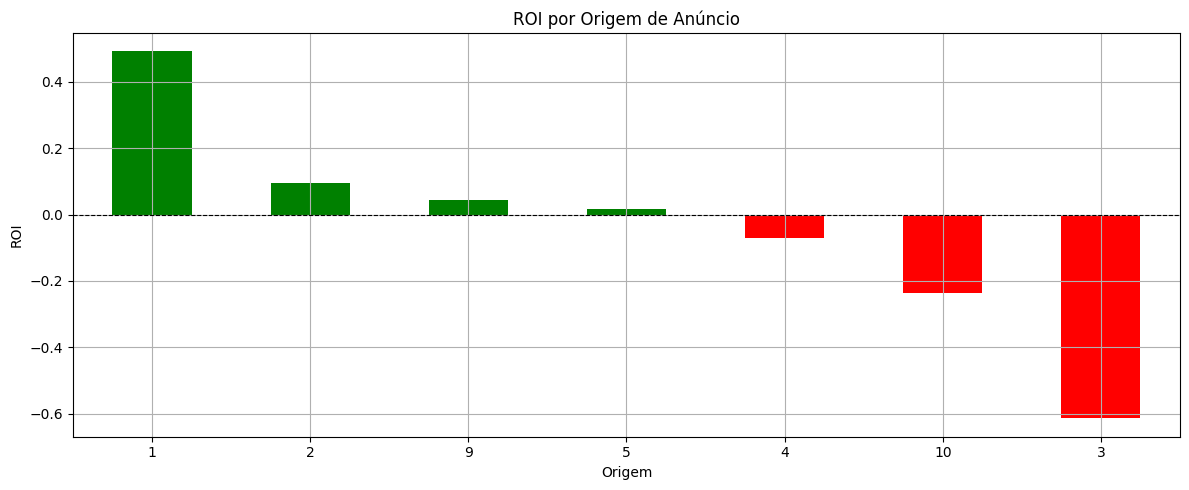

In [143]:
#ROI — Retorno sobre o Investimento por Origem
# Receita gerada por clientes de cada origem
orders_with_source = orders.merge(first_visit_source, on='Uid', how='left')
orders_with_source['Source Id'] = orders_with_source['Source Id'].astype(str)

revenue_per_source = orders_with_source.groupby('Source Id')['Revenue'].sum()

# ROI = (Receita - Custo) / Custo
roi = (revenue_per_source - cost_per_source) / cost_per_source
roi = roi.dropna().sort_values(ascending=False)

print('ROI por origem:')
print(roi.round(2))

colors = ['green' if v >= 0 else 'red' for v in roi]
roi.plot(kind='bar', title='ROI por Origem de Anúncio', color=colors)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Origem'); plt.ylabel('ROI')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Podemos obersar uma performance mista, com a Origem 1 sendo a mais lucrativa, apresentando um ROI positivo de quase 0,5. Em contrapartida, as origens 4, 10 e 3 apresentam ROI negativo, com a Origem 3 demonstrando o pior desempenho, com uma perda superior a -0,6. Isso indica que o investimento nos canais à direita (em vermelho) está gerando prejuízo, enquanto apenas os canais à esquerda (em verde) trazem retorno financeiro real.

CAC médio entre origens: $7.96


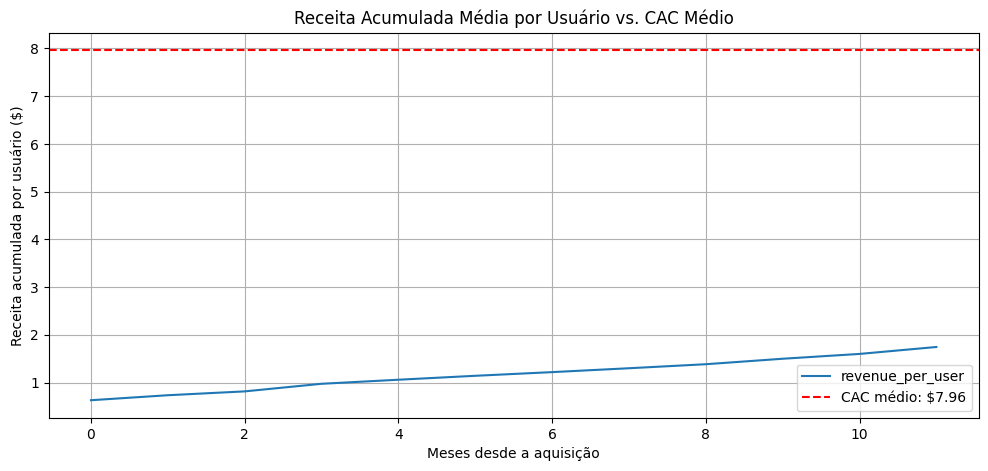

O investimento ainda não se pagou no período analisado.


In [144]:
#Payback — Quando os Investimentos se Pagam?
# Receita acumulada por coorte ao longo dos meses após aquisição
orders_cohort2 = orders.merge(
    visits[['Uid','first_visit_month','first_visit_ts']].drop_duplicates(), on='Uid', how='left'
)
orders_cohort2['months_since_acq'] = (
    (orders_cohort2['Buy Ts'].dt.to_period('M') - orders_cohort2['first_visit_month'])
    .apply(lambda x: x.n if hasattr(x, 'n') else None)
)

# Receita acumulada média por usuário, por mês desde a aquisição
cohort_size = visits[['Uid','first_visit_month']].drop_duplicates().groupby('first_visit_month')['Uid'].nunique()

revenue_by_month = (
    orders_cohort2
    .groupby(['first_visit_month','months_since_acq'])['Revenue']
    .sum()
    .reset_index()
)
revenue_by_month['revenue_per_user'] = (
    revenue_by_month['Revenue'] /
    revenue_by_month['first_visit_month'].map(cohort_size)
)

# Acumulado por meses desde aquisição (média entre coortes)
cumrev = (
    revenue_by_month
    .groupby('months_since_acq')['revenue_per_user']
    .mean()
    .cumsum()
)

cac_medio = cac.mean()
print(f'CAC médio entre origens: ${cac_medio:.2f}')

cumrev.plot(title='Receita Acumulada Média por Usuário vs. CAC Médio')
plt.axhline(cac_medio, color='red', linestyle='--', label=f'CAC médio: ${cac_medio:.2f}')
plt.xlabel('Meses desde a aquisição'); plt.ylabel('Receita acumulada por usuário ($)')
plt.legend()
plt.show()

# Identificar o mês de payback
payback_month = cumrev[cumrev >= cac_medio].index.min()
if pd.notna(payback_month):
    print(f'Payback médio: mês {payback_month} após a aquisição')
else:
    print('O investimento ainda não se pagou no período analisado.')

O gráfico compara a Receita Acumulada Média por Usuário com o Custo de Aquisição de Cliente (CAC médio) de 7,96 REAIS. A linha azul mostra que, mesmo após 11 meses da aquisição, a receita por usuário ainda está abaixo de $2, indicando que o investimento inicial para atrair cada cliente ainda não se pagou. O cenário revela um retorno sobre o investimento negativo no período analisado, já que a receita acumulada cresce muito lentamente em direção à linha de custo.

Conclusões Finais: Resumo dos Principais Achados
Problema de Retenção: A grande maioria dos usuários (77,2%) acessa o site apenas uma vez e nunca mais volta. O negócio é muito dependente de novas aquisições diárias, mas falha em manter os clientes na base.

Conversão Imediata: A jornada de compra é curta. Cerca de 72% das conversões ocorrem no mesmo dia do primeiro acesso. Se o usuário não compra nas primeiras 24 horas, as chances de ele converter depois são mínimas.

Declínio de Performance: Ao longo de um ano, a taxa de conversão caiu de 22% para 15%, e a receita das coortes mais novas é significativamente menor que a das primeiras. Isso sugere que a qualidade do tráfego atraído está piorando ou o mercado ficou mais competitivo.

Alerta de Payback: O custo de aquisição (CAC médio de $7,96) é muito alto para o retorno atual. Em média, um cliente não gera receita suficiente para cobrir o custo de sua própria "compra" nem após 11 meses, resultando em uma operação que ainda não se paga no período analisado.

Recomendação estratégica: O foco deve mudar urgentemente de "trazer qualquer volume de tráfego" para "reter usuários atuais e otimizar o investimento nos canais de alto ROI (1 e 2)"